# Isolation Forest — An Illustrated Tour

> Anomalies are **few and different**. So they are easier to isolate: a random tree slicing the feature space will isolate an outlier with far fewer splits than a normal point.

---

**What we cover:**
- The core idea — short path length = anomaly
- Building one isolation tree, by hand
- An ensemble of trees → an anomaly score
- Score map across the input plane
- Effect of `contamination` and `n_estimators`
- Comparison with One-Class SVM and LOF intuition (one figure)

## The picture — outliers need fewer random splits to be isolated

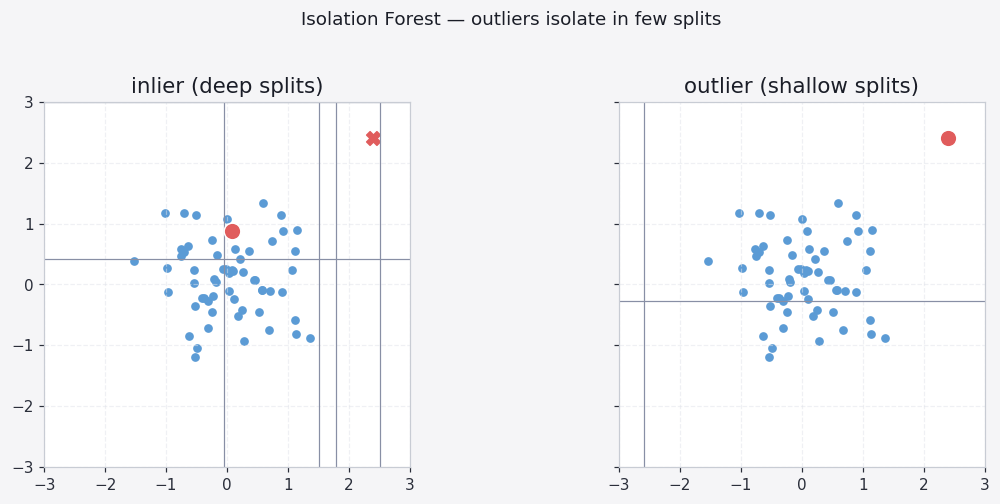

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.RandomState(0)
inliers = rng.randn(60, 2)*0.6
outlier = np.array([2.4, 2.4])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for ax, target, title, depth in [(axes[0], inliers[5], 'inlier (deep splits)', 6),
                                  (axes[1], outlier,    'outlier (shallow splits)', 2)]:
    ax.scatter(inliers[:,0], inliers[:,1], s=22, color=P[0])
    ax.scatter(*outlier, s=80, color=P[1], marker='X', label='outlier')
    # Random splits around the point until isolated
    xmin, xmax, ymin, ymax = -3, 3, -3, 3
    for _ in range(depth):
        if rng.rand() < 0.5:
            c = rng.uniform(xmin, xmax)
            ax.axvline(c, color='#888fa5', lw=0.8)
            if target[0] < c: xmax = c
            else:             xmin = c
        else:
            c = rng.uniform(ymin, ymax)
            ax.axhline(c, color='#888fa5', lw=0.8)
            if target[1] < c: ymax = c
            else:             ymin = c
    ax.scatter(*target, s=120, color=P[1], edgecolor='white', zorder=5)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal')
    ax.set_title(title); ax.grid(True)
fig.suptitle('Isolation Forest — outliers isolate in few splits', y=1.03)
plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import make_blobs

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7', 'axes.facecolor':'#ffffff',
    'axes.edgecolor':'#c8ccd4',   'axes.labelcolor':'#1a1d27',
    'axes.titlecolor':'#1a1d27',  'xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a',      'grid.color':'#e0e3ea',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'text.color':'#1a1d27',       'font.family': 'DejaVu Sans',
    'axes.titlesize': 17,          'axes.labelsize': 13,
    'xtick.labelsize': 11,         'ytick.labelsize': 11,
    'legend.fontsize': 11,         'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4', 'figure.dpi': 120,
}
plt.rcParams.update(PLT_STYLE)

C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'; CH='#56b6c2'; CP='#c678dd'

# Toy 2-D dataset: two normal clusters + scattered outliers
rng = np.random.default_rng(7)
X_in, _ = make_blobs(n_samples=240, centers=[(0, 0), (4, 4)],
                     cluster_std=0.7, random_state=7)
X_out = rng.uniform(low=-4, high=8, size=(30, 2))
X = np.vstack([X_in, X_out])
y_true = np.r_[np.ones(len(X_in)), -np.ones(len(X_out))]  # +1 normal, -1 outlier

xx, yy = np.meshgrid(np.linspace(-5, 9, 250), np.linspace(-5, 9, 250))
grid = np.c_[xx.ravel(), yy.ravel()]
print('Dataset:', X.shape, '— normal:', (y_true==1).sum(), ' outliers:', (y_true==-1).sum())

Dataset: (270, 2) — normal: 240  outliers: 30


---
## The Core Idea — Path Length

An **isolation tree** repeatedly picks a random feature and a random split value inside the data range. It keeps splitting until every point is alone in its leaf.

- A point in a **dense cluster** is hard to isolate — it takes many splits.
- A point **far from the rest** falls off after 1–2 splits.

The **path length** $h(x)$ (number of splits to isolate $x$) is the raw anomaly signal. Averaged over many random trees, the expected path length $E[h(x)]$ is small for anomalies and large for normal points.

The anomaly score is

$$s(x, n) = 2^{-\,E[h(x)] / c(n)}$$

where $c(n)$ normalises by the average path length in a random tree on $n$ points. $s \to 1$ means "anomaly", $s \to 0.5$ means "normal".

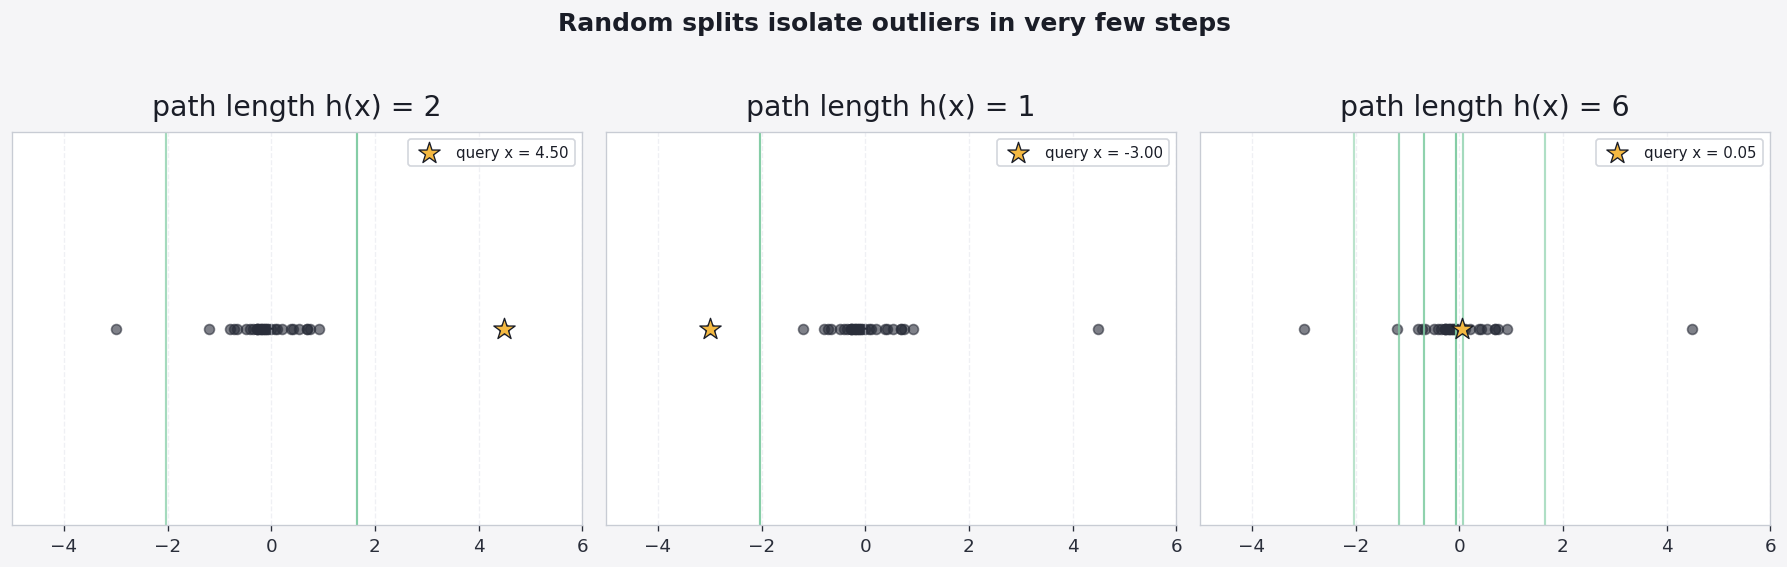

In [3]:
# Manually grow a tiny isolation tree on a 1-D slice to show how splits isolate outliers fast
x1 = np.r_[rng.normal(0.0, 0.6, 30), [4.5, -3.0]]  # 2 outliers at the ends

def isolate_path(value, points, rng_local, max_depth=12):
    """Return list of split values used until `value` is alone in its leaf."""
    pts = np.array(points)
    splits = []
    for _ in range(max_depth):
        if len(pts) <= 1:
            break
        lo, hi = pts.min(), pts.max()
        if hi - lo < 1e-9:
            break
        s = rng_local.uniform(lo, hi)
        splits.append(s)
        pts = pts[pts < s] if value < s else pts[pts >= s]
    return splits

paths = {v: isolate_path(v, x1, np.random.default_rng(11)) for v in [4.5, -3.0, 0.05]}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (val, splits) in zip(axes, paths.items()):
    ax.scatter(x1, np.zeros_like(x1), c='#2a2e3a', s=35, alpha=0.6)
    ax.scatter([val], [0], s=180, c=CB, marker='*', zorder=5,
               edgecolors='#1a1d27', lw=0.8, label=f'query x = {val:.2f}')
    for i, s in enumerate(splits):
        ax.axvline(s, color=CM, lw=1.3, alpha=0.45 + 0.5*(i+1)/len(splits))
    ax.set_title(f'path length h(x) = {len(splits)}', pad=10)
    ax.set_xlim(-5, 6); ax.set_yticks([])
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, axis='x')
fig.suptitle('Random splits isolate outliers in very few steps',
             fontsize=15, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

---
## Score Map — What the Forest Sees

Each tree votes on "how isolated is this point?" The forest averages the votes and produces a smooth **anomaly score surface** across the feature space.

- Bright (yellow) bands = high anomaly score.
- Dark valleys = the model considers this region normal.
- The decision boundary is the contour where the score crosses zero (`decision_function = 0`).

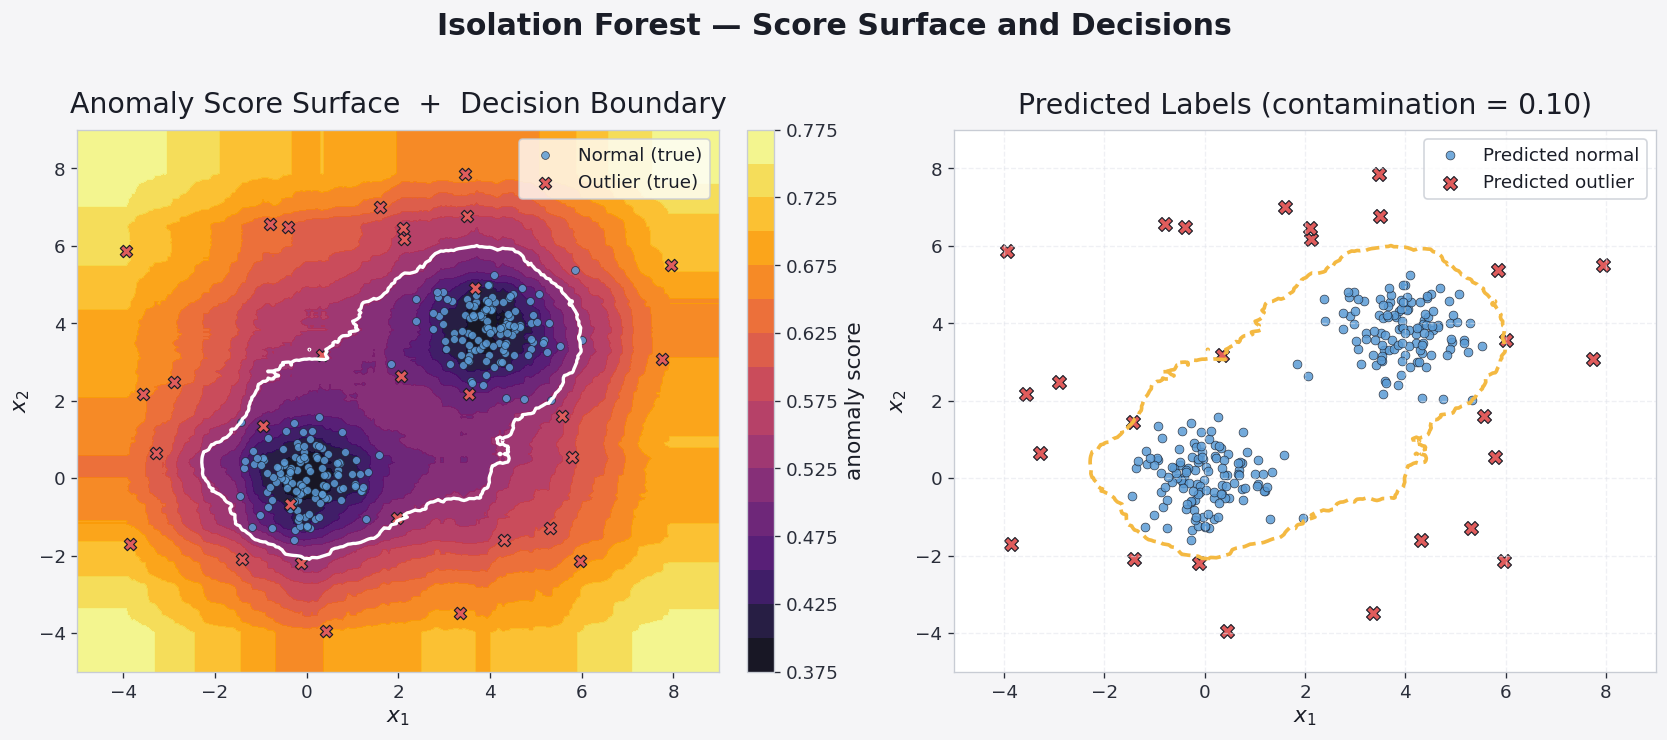

In [4]:
iso = IsolationForest(n_estimators=200, contamination=0.10, random_state=0).fit(X)
score = -iso.score_samples(grid).reshape(xx.shape)   # higher = more anomalous
boundary = iso.decision_function(grid).reshape(xx.shape)
preds = iso.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
cf = ax.contourf(xx, yy, score, levels=18, cmap='inferno', alpha=0.92)
ax.contour(xx, yy, boundary, levels=[0], colors='#ffffff', linewidths=2.0)
ax.scatter(X_in[:,0], X_in[:,1], c=C0, s=22, edgecolors='#1a1d27', lw=0.4, alpha=0.85, label='Normal (true)')
ax.scatter(X_out[:,0], X_out[:,1], c=C1, s=55, marker='X', edgecolors='#1a1d27', lw=0.7, label='Outlier (true)')
ax.set_title('Anomaly Score Surface  +  Decision Boundary', pad=10)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.legend(loc='upper right'); ax.grid(False)
plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.04, label='anomaly score')

ax = axes[1]
ax.scatter(X[preds==1, 0],  X[preds==1, 1], c=C0, s=28, edgecolors='#1a1d27', lw=0.4, alpha=0.85, label='Predicted normal')
ax.scatter(X[preds==-1, 0], X[preds==-1, 1], c=C1, s=70, marker='X', edgecolors='#1a1d27', lw=0.7, label='Predicted outlier')
ax.contour(xx, yy, boundary, levels=[0], colors=CB, linewidths=2.2, linestyles='--')
ax.set_title('Predicted Labels (contamination = 0.10)', pad=10)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.legend(loc='upper right'); ax.grid(True)

fig.suptitle('Isolation Forest — Score Surface and Decisions',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## Effect of Hyperparameters

Two knobs matter most:

- **`contamination`** — the expected fraction of outliers. It shifts the threshold on the score, *not* the score itself. Too high → too many normals get flagged. Too low → missed anomalies.
- **`n_estimators`** — number of random trees. More trees → smoother, more stable score surface. Returns diminish quickly past ~100.

The grid below shows boundaries across both knobs.

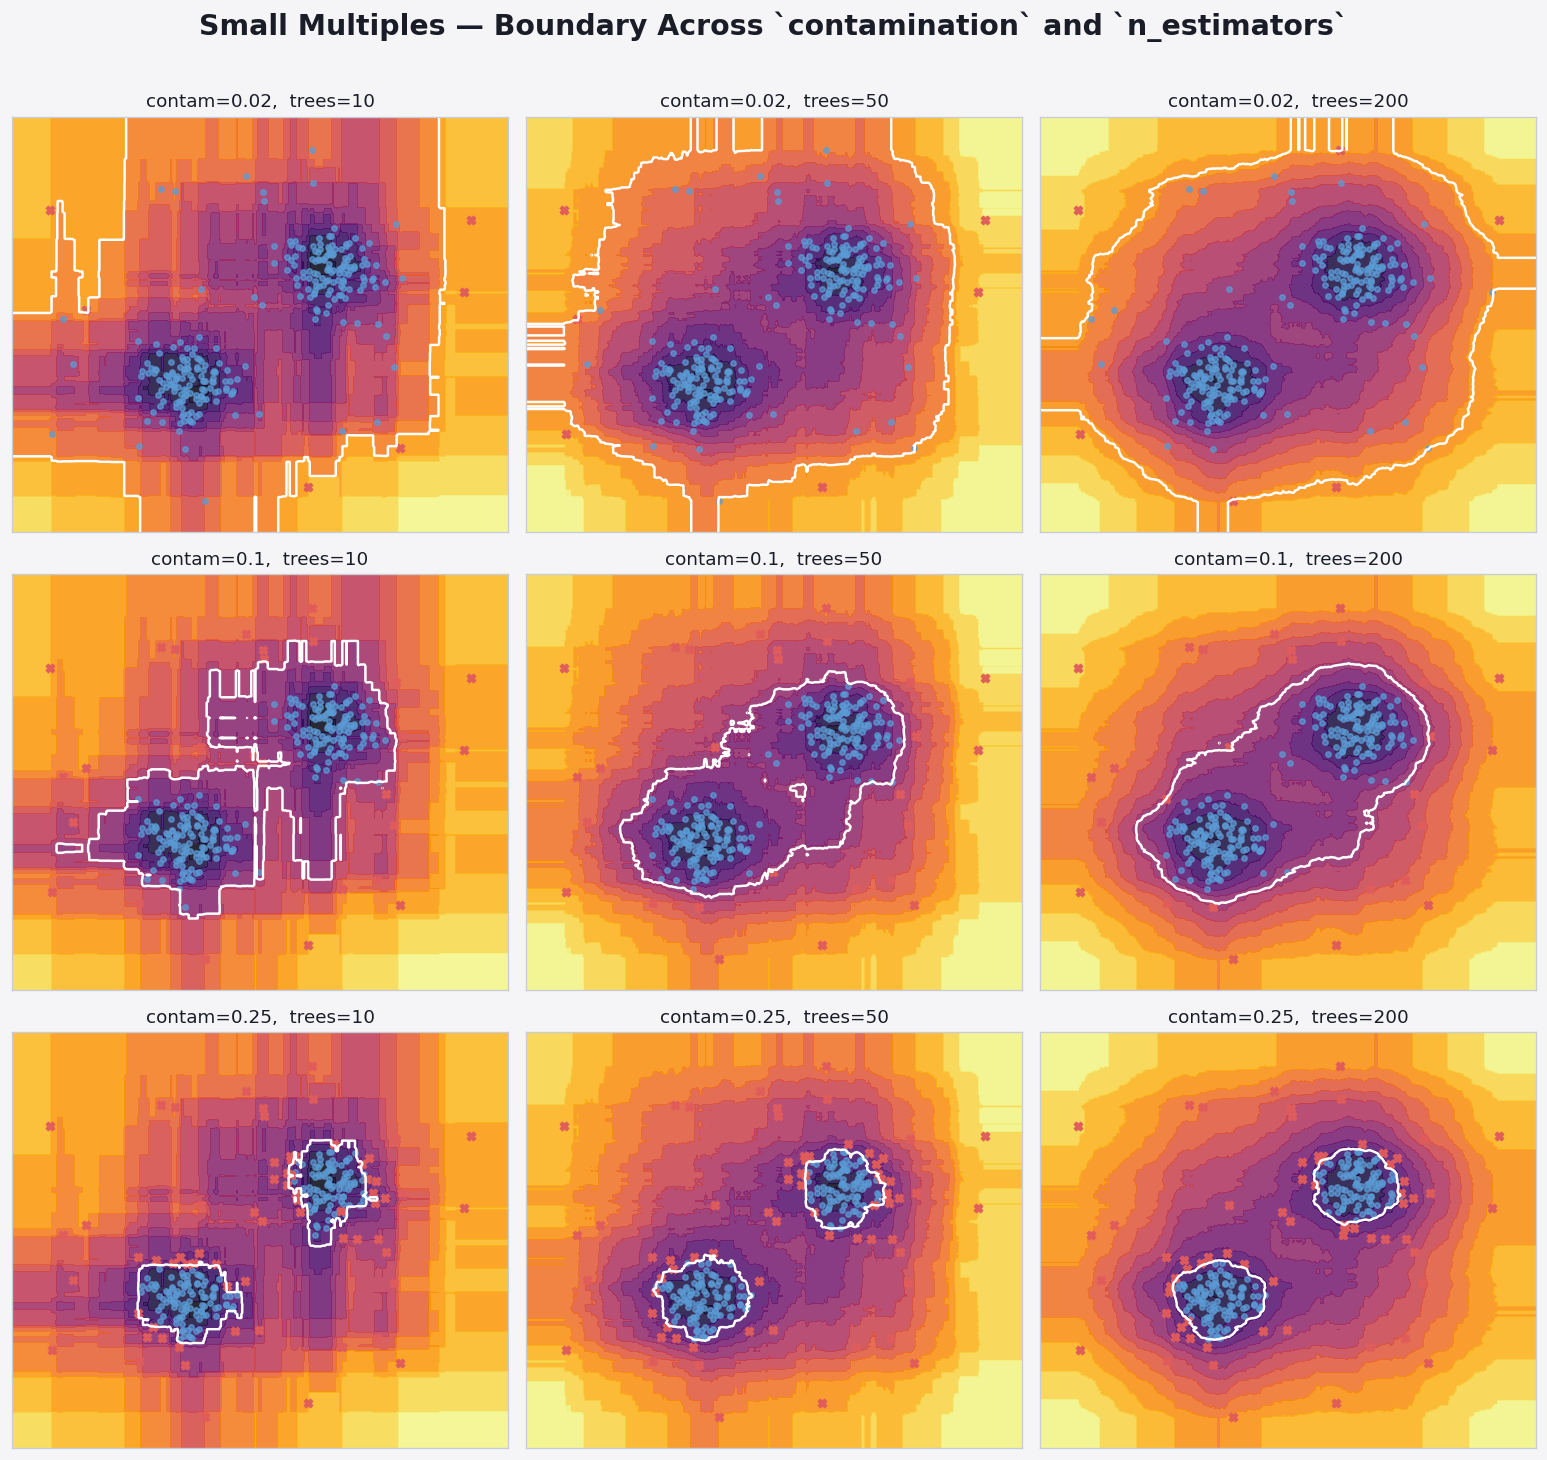

In [5]:
contaminations = [0.02, 0.10, 0.25]
n_trees_list   = [10, 50, 200]

fig, axes = plt.subplots(3, 3, figsize=(13, 12))
for r, c_val in enumerate(contaminations):
    for c, n_t in enumerate(n_trees_list):
        m = IsolationForest(n_estimators=n_t, contamination=c_val, random_state=0).fit(X)
        b = m.decision_function(grid).reshape(xx.shape)
        s = -m.score_samples(grid).reshape(xx.shape)
        p = m.predict(X)
        ax = axes[r, c]
        ax.contourf(xx, yy, s, levels=14, cmap='inferno', alpha=0.85)
        ax.contour(xx, yy, b, levels=[0], colors='#ffffff', linewidths=1.5)
        ax.scatter(X[p==1,0],  X[p==1,1], c=C0, s=10, alpha=0.7)
        ax.scatter(X[p==-1,0], X[p==-1,1], c=C1, s=24, marker='X', alpha=0.95)
        ax.set_title(f'contam={c_val:g},  trees={n_t}', fontsize=11, pad=6)
        ax.set_xticks([]); ax.set_yticks([])

fig.suptitle('Small Multiples — Boundary Across `contamination` and `n_estimators`',
             fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Where Isolation Forest Wins and Loses

Three classic anomaly-detection scenarios, three families of methods:

| Method | What it models | Weakness |
|---|---|---|
| **Isolation Forest** | Path-length of axis-aligned random splits | Struggles when normal data lies on a thin curved manifold (boundaries are axis-aligned) |
| **One-Class SVM** | Boundary in a kernel-induced feature space | Sensitive to `nu` and `gamma`; expensive on big data |
| **Local Outlier Factor** | Local density vs neighbors' density | Doesn't generalise to new points without `novelty=True` |

The next figure runs all three on the same data so you can compare their *shape* of decision.

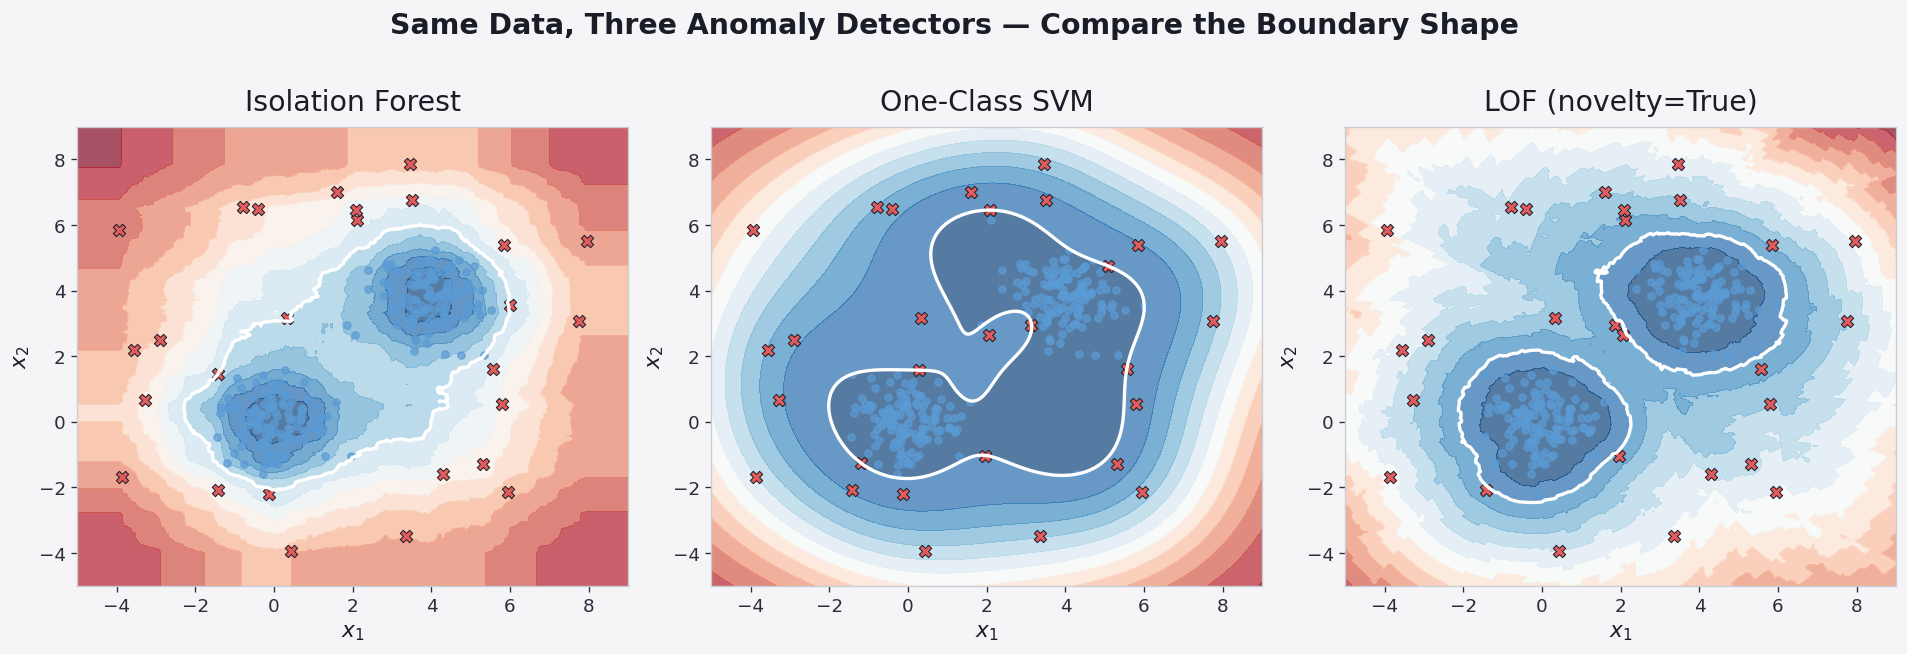

In [6]:
ocsvm = OneClassSVM(kernel='rbf', gamma=0.10, nu=0.10).fit(X)
lof   = LocalOutlierFactor(n_neighbors=20, contamination=0.10, novelty=True).fit(X)

models = [
    ('Isolation Forest', iso),
    ('One-Class SVM',    ocsvm),
    ('LOF (novelty=True)', lof),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.3))
for ax, (name, m) in zip(axes, models):
    b = m.decision_function(grid).reshape(xx.shape)
    p = m.predict(X)
    ax.contourf(xx, yy, b, levels=14, cmap='RdBu', alpha=0.7)
    ax.contour(xx, yy, b, levels=[0], colors='#ffffff', linewidths=2)
    ax.scatter(X[p==1,0],  X[p==1,1], c=C0, s=18, alpha=0.7)
    ax.scatter(X[p==-1,0], X[p==-1,1], c=C1, s=55, marker='X', edgecolors='#1a1d27', lw=0.6)
    ax.set_title(name, pad=10)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.grid(False)

fig.suptitle('Same Data, Three Anomaly Detectors — Compare the Boundary Shape',
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## ⚖️ When to use Isolation Forest — and when not to

| Situation | Isolation Forest | LOF | One-Class SVM | Autoencoder |
|---|---|---|---|---|
| High-D tabular data | ✅ | partial | ✅ | ✅ |
| Outliers form a global tail | ✅ | ❌ | ✅ | ✅ |
| Outliers are *locally* sparse | ❌ | ✅ | partial | partial |
| Need fast scoring at predict time | ✅ tree depth | ❌ neighbours | ✅ | ✅ |

> The default anomaly detector for **tabular** data — fast, robust, and almost no tuning.


---
## 🎯 Try this

1. **Contamination sweep.** Vary `contamination` in $\{0.01, 0.05, 0.1, 0.2\}$ and observe how the threshold (and false positives) shift.
2. **Feature scaling.** Confirm Isolation Forest is largely **invariant to monotonic transforms** of features — unlike LOF/OCSVM which are not.
3. **Path-length intuition.** For a few flagged outliers, plot the average path length across trees. The deepest contrast vs the population is what makes them anomalies.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Path length $h(x)$ | Splits needed to isolate $x$ in a random tree | Short = anomaly, long = normal |
| Anomaly score $s(x)$ | $2^{-E[h(x)]/c(n)}$ averaged over trees | Bounded in $(0, 1)$; near 1 = anomaly |
| `n_estimators` | Number of trees in the forest | More trees → smoother score; saturates ~100 |
| `contamination` | Expected outlier fraction | Sets the threshold; does not change the score surface |
| Strength | Linear in $n$, no distance assumptions, scales | Great default for tabular anomaly detection |
| Weakness | Axis-aligned splits | Misses anomalies hiding inside curved manifolds |

**Bottom line:** Isolation Forest turns the anomaly-detection problem into a **counting problem** — how many random axis cuts does it take to isolate this point? Anomalies, being few and different, are isolated quickly, and the score is the average across hundreds of random trees.